In [31]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(3)


(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


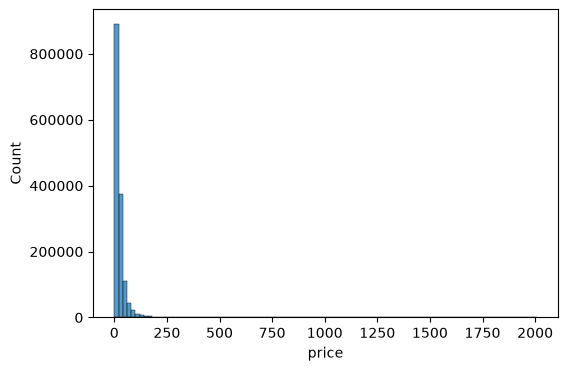

price
0.0         874
3.0       18703
4.0       16139
5.0       31502
5.5          33
          ...  
1999.0        1
2000.0        6
2004.0        1
2006.0        1
2009.0        1
Name: count, Length: 828, dtype: int64

In [32]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

#원본 보관(백업용) 및 답 임시생성(그래프 생성용)
mercari_ori= mercari_df
y_labels = mercari_df['price']

plt.figure(figsize=(6,4))
sns.histplot(y_labels, bins=100)
plt.show()




mercari_df.value_counts('price').sort_index()

# y_labels 0처리 이후 다시 재조정예정


In [33]:
# 전처리전 체크
print(f'전처리 전 : {mercari_df.shape}')

# 가격이 0인 데이터 제거
mercari_df = mercari_df[mercari_df['price']>0]
print(f'0 제거 후 : {mercari_df.shape}')

# 가격이 2000이상인 데이터 제거
mercari_df = mercari_df[mercari_df['price']<2000]
print(f'2000이상 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)

print(f'train_id 제거 후 : {mercari_df.shape}')

# 추가: 브랜드 and의 전처리(불용어 and와 겹치지 않게끔 전처리 진행)
mercari_df['brand_name'] = (
    mercari_df['brand_name']
    .str.replace(r'\bAND\b', 'brand_and', regex=True)
)

mercari_df['brand_name'].str.contains(
    r'\bbrand_and\b',
    na=False
).sum()

전처리 전 : (1482535, 8)
0 제거 후 : (1481661, 8)
2000이상 제거 후 : (1481652, 8)
train_id 제거 후 : (1481603, 7)


np.int64(1933)

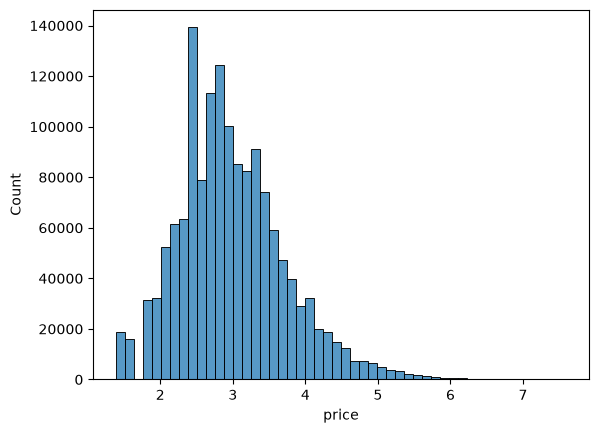

In [34]:
import numpy as np

y_labels = mercari_df['price']

mercari_df['price']= np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [35]:
# 'decription'만 텍스트 전처리(나머지는 알아서!)
# 모듈 불러오기
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

#텍스트 클리닝(소문자/공백)
def text_cleaning(text):
    
    # 소문자로 변환
    text = text.lower()
    
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

# 불용어 목록에서 부정 표현 제외
stop_words = stop_words - negative_words


In [36]:
mercari_df['item_description'].apply(type).value_counts()

item_description
<class 'str'>      1481597
<class 'float'>          6
Name: count, dtype: int64

In [37]:
#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 함수

def preprocess_text(text):
     # 1. 소문자 / 영문자 / 공백 정리
    text = text_cleaning(text)

    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)

    # 3. 불용어 제거
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return tokens


def preprocess_description(text):
    # 1. 결측치 처리 + 문자열 변환
    if pd.isna(text):
        text = 'No description yet'
    

    # 2. 클렌징 + 토큰화 + 불용어 제거
    tokens = preprocess_text(text)

    # 3. 리스트 → 문자열
    text = ' '.join(tokens)

    return text




In [38]:
mercari_df['item_description'] = (
    mercari_df['item_description']
    .apply(preprocess_description)
)
# 클렌징 및 토큰화 후, 최종 확인
mercari_df['item_description'].head()

0                                   no description yet
1    keyboard great condition works like came box p...
2    adorable top hint lace key hole back pale pink...
3    new tags leather horses retail stand foot high...
4                    complete certificate authenticity
Name: item_description, dtype: str

In [39]:
#프로덕트 텍스트 새로 생성(name,brand_name, category_name) 함수 제작
def make_product_text(df):
    df['product_text'] = (
        df['name'].fillna('') + ' ' +
        df['brand_name'].fillna('') + ' ' +
        df['category_name'].fillna('').str.replace('/', ' ', regex=False)
    )

    df['product_text'] = (
        df['product_text']
        .apply(preprocess_text)
        .apply(lambda x: ' '.join(x))
    )

    return df

def fix_item_description(df):
    df[['item_description']=='no description yet'] = ' '
    df['item_description'] = (
    df['name'].fillna('') + ' ' +
    df['item_description'].fillna('')
    )
    
    return df

In [40]:
make_product_text(mercari_df)
fix_item_description(mercari_df)
mercari_df['product_text']

0          mlb cincinnati reds shirt size xl men tops shirts
1          razer blackwidow chroma keyboard razer electro...
2            ava viv blouse target women tops blouses blouse
3          leather horse statues home home cor home cor a...
4               24k gold plated rose women jewelry necklaces
                                 ...                        
1481598    free people inspired dress free people women d...
1481599    little mermaid handmade dress disney kids girl...
1481600    21 day fix containers eating plan sports outdo...
1481601    world markets lanterns home home cor home cor ...
1481602    brand new lux de ville wallet women women acce...
Name: product_text, Length: 1481603, dtype: str

In [41]:
#item_description에 이름 넣기
mercari_df[['item_description']=='not description yet'] = ' '
mercari_df['item_description'] = (
    mercari_df['name'].fillna('') + ' ' +
    mercari_df['item_description'].fillna('')
)

In [42]:
#단어와 길이도 한번 넣어보기로

# product_text 길이
mercari_df['product_text_len'] = (
    mercari_df['product_text'].str.len()
)

# product_text 단어 수
mercari_df['product_text_word_count'] = (
    mercari_df['product_text'].str.split().str.len()
)

# description 길이
mercari_df['description_len'] = (
    mercari_df['item_description'].str.len()
)

# description 단어 수
mercari_df['description_word_count'] = (
    mercari_df['item_description'].str.split().str.len()
)

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = (
    train_test_split(
        mercari_df[['product_text','item_description','item_condition_id','shipping',
        'product_text_len','product_text_word_count','description_len','description_word_count']
        ],
        y_labels,
        test_size=0.2,
        random_state=42
    )
)

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 상품명 + 브랜드 + 카테고리
product_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=200000
)

# 상품 설명
description_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=200000
)

In [61]:
def tfidf_transform(
    X_train,
    X_valid,
    product_tfidf,
    description_tfidf
):
    # product_text
    X_train_product = product_tfidf.fit_transform(
        X_train['product_text']
    )
    X_valid_product = product_tfidf.transform(
        X_valid['product_text']
    )

    # item_description
    X_train_desc = description_tfidf.fit_transform(
        X_train['item_description']
    )
    X_valid_desc = description_tfidf.transform(
        X_valid['item_description']
    )

    return (
        X_train_product,
        X_valid_product,
        X_train_desc,
        X_valid_desc
    )

In [62]:
X_train_product, X_valid_product, X_train_desc, X_valid_desc = (
    tfidf_transform(
        X_train,
        X_valid,
        product_tfidf,
        description_tfidf
    )
)

In [72]:
from scipy.sparse import csr_matrix, hstack
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from lightgbm import LGBMRegressor

# 텍스트 데이터 hstack으로 합침. 희소행렬형식을 csr로 확정
X_train_text = hstack([
    X_train_product,
    X_train_desc
]).tocsr()
X_valid_text = hstack([
    X_valid_product,
    X_valid_desc
]).tocsr()

In [74]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_oof = np.zeros(len(X_train))
ridge_valid_preds = np.zeros((len(X_valid), 5))



In [77]:
for fold, (train_idx, val_idx) in enumerate(
    kf.split(X_train_text)
):

    print(f"Fold {fold + 1}")

    X_tr = X_train_text[train_idx]
    X_val = X_train_text[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    ridge_fold = Ridge(
        alpha=2.0
    )

    ridge_fold.fit(
        X_tr,
        y_tr
    )

    # OOF prediction
    ridge_oof[val_idx] = ridge_fold.predict(
        X_val
    )

    # 최종 validation prediction
    ridge_valid_preds[:, fold] = ridge_fold.predict(
        X_valid_text
    )

    fold_score = np.sqrt(
        mean_squared_error(
            y_val,
            ridge_oof[val_idx]
        )
    )

    print(
        f"Fold {fold + 1} RMSLE:",
        fold_score
    )


ridge_valid_mean = ridge_valid_preds.mean(axis=1)



Fold 1
Fold 1 RMSLE: 0.44433191589586957
Fold 2
Fold 2 RMSLE: 0.4442760151137944
Fold 3
Fold 3 RMSLE: 0.4437632394115591
Fold 4
Fold 4 RMSLE: 0.44464760810961107
Fold 5
Fold 5 RMSLE: 0.44480617246121784


In [78]:
#OOF Ridge 스코어
ridge_oof_score = np.sqrt(
    mean_squared_error(
        y_train,
        ridge_oof
    )
)

print(
    "OOF Ridge RMSLE:",
    ridge_oof_score
)

OOF Ridge RMSLE: 0.44436513538771394


In [79]:
# 새로운 LGBM적용 train valid 데이터 사용

lgbm_features=[
    'item_condition_id',
    'shipping',
    'product_text_len',
    'product_text_word_count',
    'description_len',
    'description_word_count'
]
X_train_lgbm = X_train[lgbm_features].copy()
X_valid_lgbm = X_valid[lgbm_features].copy()

X_train_lgbm['ridge_pred'] = ridge_oof
X_valid_lgbm['ridge_pred'] = ridge_valid_mean

In [80]:
from lightgbm import LGBMRegressor

lgbm_support = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

lgbm_support.fit(
    X_train_lgbm,
    y_train
)

pred_final = lgbm_support.predict(
    X_valid_lgbm
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 818
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 7
[LightGBM] [Info] Start training from score 2.980810


In [81]:
from sklearn.metrics import mean_squared_error
import numpy as np

score = np.sqrt(
    mean_squared_error(
        y_valid,
        pred_final
    )
)

print("Ridge → LGBM Support RMSLE:", score)

Ridge → LGBM Support RMSLE: 0.43119211977674443


In [82]:
ridge_valid_score = np.sqrt(
    mean_squared_error(
        y_valid,
        ridge_valid_mean
    )
)

print(
    "Ridge Validation RMSLE:",
    ridge_valid_score
)

print(
    "Stacking Validation RMSLE:",
    score
)

Ridge Validation RMSLE: 0.4424956833367636
Stacking Validation RMSLE: 0.43119211977674443


In [ ]:
#앙상블진행했을 때 비율
# pred_final = (
#     0.8 * pred_ridge +
#     0.2 * pred_lgbm
# )

In [ ]:
# #비율 치 조정

# for rw in [0.6, 0.7, 0.8, 0.9 , 0.95, 0.99]:
#     lw = 1 - rw

#     pred_ensemble = (
#         rw * pred_ridge +
#         lw * pred_lgbm
#     )

#     score = np.sqrt(
#         mean_squared_error(
#             y_valid,
#             pred_ensemble
#         )
#     )

#     print(
#         f"Ridge {rw:.1f} / "
#         f"LGBM {lw:.1f} -> "
#         f"{score:.6f}"
#     )

Ridge 0.6 / LGBM 0.4 -> 0.484530
Ridge 0.7 / LGBM 0.3 -> 0.463931
Ridge 0.8 / LGBM 0.2 -> 0.449629
Ridge 0.9 / LGBM 0.1 -> 0.442236
Ridge 0.9 / LGBM 0.1 -> 0.441252
Ridge 1.0 / LGBM 0.0 -> 0.441784


In [ ]:
score = np.sqrt(
    mean_squared_error(
        y_valid,
        pred_final
    )
)

print("Ensemble RMSLE:", score)

Ensemble RMSLE: 0.44962903618459493


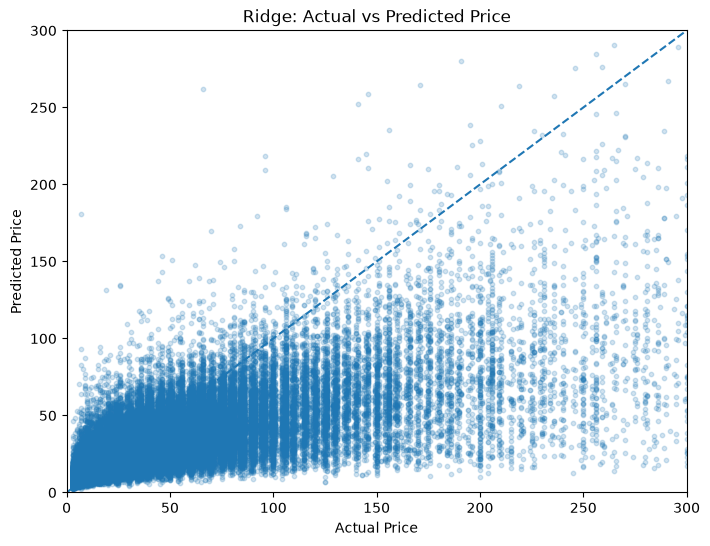

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

actual_price = np.expm1(y_valid)
pred_price = np.expm1(pred_final)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_price,
    pred_price,
    alpha=0.2,
    s=10
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Ridge: Actual vs Predicted Price')

plt.xlim(0, 300)
plt.ylim(0, 300)

plt.plot(
    [0, 300],
    [0, 300],
    linestyle='--'
)

plt.show()

In [ ]:
import numpy as np
import pandas as pd

product_features = [
    'product_' + x
    for x in product_tfidf.get_feature_names_out()
]

desc_features = [
    'desc_' + x
    for x in description_tfidf.get_feature_names_out()
]

num_features = [
    'item_condition_id',
    'shipping'
]

feature_names = (
    product_features
    + desc_features
    + num_features
)

In [ ]:
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': ridge.coef_
})

ValueError: All arrays must be of the same length

In [ ]:
coef_df.head()

,feature,coef
0,product_00,-0.211186
1,product_00 abercrombie,-0.009709
2,product_00 american,-0.114658
3,product_00 beauty,-0.110031
4,product_00 carat,-0.200240


In [ ]:
negative_features = (
    coef_df
    .sort_values('coef', ascending=True)
    .head(20)
)

negative_features

,feature,coef
29249,product_dust bag,-2.072668
19883,product_charger,-1.443780
85165,product_sticker,-1.435815
29254,product_dustbag,-1.293774
29248,product_dust,-1.214864
129676,desc_envelope,-1.195041
85196,product_stickers,-1.140566
18940,product_case,-1.131465
113528,desc_box only,-1.115772
14197,product_box louis,-1.109908


In [ ]:
positive_features = (
    coef_df
    .sort_values('coef', ascending=False)
    .head(20)
)

positive_features

,feature,coef
100990,desc_14k,2.448408
100454,desc_10k,1.908654
100790,desc_128gb,1.849971
192736,desc_unlocked,1.798615
148816,desc_limbs,1.795557
76536,product_scott women,1.692468
38631,product_gucci,1.657419
103569,desc_64gb,1.634398
42879,product_inr,1.622621
101174,desc_16gb,1.612253
